# VIBES_PIPE Part 1: Data Prep + Manifest + Preprocess Demo

This notebook demonstrates that the current pipeline components work end-to-end:

- Create/verify `pairs.json` for subject folders
- Run the `prep` CLI to snapshot data into a workspace
- Inspect `manifest.json` (dataset snapshot)
- Load one subject and run preprocessing (CLAHE → resample → resize → normalize)
- Confirm output shapes and basic sanity checks

> Assumptions:
> - Your repo is at `/files/smooi/Desktop/vibes_pipe`
> - You already have a `pairs.json` under `experiments/mre_data_prep_test/`
> - Your `.mat` does NOT contain spacing, and spacing comes from the companion `.nii/.nii.gz`

In [1]:
import os
from pathlib import Path

REPO = Path("/files/smooi/Desktop/vibes_pipe").resolve()
EXP  = REPO / "experiments" / "mre_data_prep_test"
PAIRS_JSON = EXP / "pairs.json"
WORKSPACE  = EXP / "workspace_root"
MANIFEST   = WORKSPACE / "manifest.json"

print("REPO:", REPO)
print("EXP:", EXP)
print("PAIRS_JSON exists:", PAIRS_JSON.exists())
print("WORKSPACE:", WORKSPACE)
print("MANIFEST exists:", MANIFEST.exists())

# Make sure Python can import vibes_pipe without installing as a package
os.environ["PYTHONPATH"] = str(REPO / "src")
print("PYTHONPATH set to:", os.environ["PYTHONPATH"])

REPO: /files/smooi/Desktop/vibes_pipe
EXP: /files/smooi/Desktop/vibes_pipe/experiments/mre_data_prep_test
PAIRS_JSON exists: True
WORKSPACE: /files/smooi/Desktop/vibes_pipe/experiments/mre_data_prep_test/workspace_root
MANIFEST exists: True
PYTHONPATH set to: /files/smooi/Desktop/vibes_pipe/src


## A) (CLI) Generate `pairs.json` from subject folders

Pairs.json is a file path manager which records all the data's file path and data split. We can write the pairs.json manually or updated with the script - "vibes_pipe/src/vibes_pipe/data/make_pairs_from_subject_folders.py". 

Why we need this step: Your `prep` command expects a `pairs.json` file that describes **where each subject’s files live** (raw paths), so the CLI can copy them into a reproducible workspace and generate `manifest.json`.

Your raw_data folder typically contains one folder per subject, e.g.
raw_data/G009/G009_t2stack.mat, raw_data/G009/G009_mask.mat, raw_data/G009/G009_t2stack.nii, etc.

```text
raw_data/
G009/
G009_t2stack.mat
G009_t2stack.nii
G009_mask.mat
G009_Mu.mat
G039/
...

In [9]:
# Two different modes of spliting:

# Standard build + reproducible split
# [Example] python update_pairs.py --root /data/mre --out /data/pairs.json --split auto --seed 42 --report /data/pairs_report.json
#!python update_pairs.py --root /home/smooi/Desktop/vibes_pipe/experiments/mre_data_prep_test/raw_data --out /home/smooi/Desktop/vibes_pipe/experiments/mre_data_prep_test/pairs.json --split auto --seed 42 
# Keep existing splits (useful if you later add new fields but don’t want split changes)
#[Example] python update_pairs.py --root /data/mre --split keep

# We are enforcing the splitting at the very beginning. 
# That will let us to (a) easier to reproduce result, and (b) makes the entire organization easier. 

import sys
sys.path.append("/files/smooi/Desktop/vibes_pipe/src")
!python -m vibes_pipe.data.make_pairs_from_subject_folders \
  --root /home/smooi/Desktop/vibes_pipe/experiments/mre_data_prep_test/raw_data \
  --out /home/smooi/Desktop/vibes_pipe/experiments/toast_data/pairs.json \
  --split auto \
  --seed 42

✅ Wrote 3 subjects to: /files/smooi/Desktop/vibes_pipe/experiments/toast_data/pairs.json
   Skipped: 0 / Found: 3


In [10]:
# Let's try with another bigger dataset
import sys
sys.path.append("/files/smooi/Desktop/vibes_pipe/src")
!python -m vibes_pipe.data.make_pairs_from_subject_folders \
  --root /home/smooi/Desktop/toast/data/toast_pipe_data \
  --out /home/smooi/Desktop/vibes_pipe/experiments/toast_data/pairs.json \
  --split auto \
  --seed 42

✅ Wrote 135 subjects to: /files/smooi/Desktop/vibes_pipe/experiments/toast_data/pairs.json
   Skipped: 0 / Found: 135


## B) (CLI) Run `prep` to build workspace + manifest

What is `manifest.json`?

`manifest.json` is a **reproducible snapshot** of your dataset in a stable workspace layout.

It records:
- `workspace_root`: absolute folder path where the snapshot lives
- `pairs`: list of items each with:
  - `id`, `split`
  - `files`: where each file was copied (`dst` is workspace-relative)
  - `sha256`: optional hash for integrity checking
  - `meta.geometry_preprocess`: original shapes + spacing (spacing comes from X_nii)

Why it matters:
- training/inference should use **workspace files**, not raw files
- if raw files change, your experiment remains reproducible

This command:
- validates `pairs.json`
- copies files into `workspace_root/{train,val,test}/{id}/`
- writes `workspace_root/manifest.json`

Run:

In [ ]:
import sys
sys.path.append("/files/smooi/Desktop/vibes_pipe/src")
# Run the below lines in your terminal!
!python -m vibes_pipe.cli.pipeline_cli prep \
  --pairs_json experiments/mre_data_prep_test/pairs.json \
  --out_dir experiments/mre_data_prep_test/workspace_root

In [12]:
# Let's try with another bigger dataset
import sys
sys.path.append("/files/smooi/Desktop/vibes_pipe/src")
!python -m vibes_pipe.cli.pipeline_cli prep \
  --pairs_json /home/smooi/Desktop/vibes_pipe/experiments/toast_data/pairs.json \
  --out_dir /home/smooi/Desktop/vibes_pipe/experiments/toast_data/workspace_root
  

[prep] Workspace created at: /files/smooi/Desktop/vibes_pipe/experiments/toast_data/workspace_root
[prep] Manifest written to:  /files/smooi/Desktop/vibes_pipe/experiments/toast_data/workspace_root/manifest.json
[prep] Num pairs: 135


Below, I will show you what a manifest.json looks like. 

In [17]:
import json
from pathlib import Path

root = Path("/home/smooi/Desktop/vibes_pipe/experiments/mre_data_prep_test/workspace_root")
mani_place = root / "manifest.json"

with open(mani_place, 'r') as f:
    data = json.load(f)
    
data.keys()

dict_keys(['schema_version', 'created_utc', 'workspace_root', 'splits', 'pairs'])

In [ ]:
import pandas as pd

df = pd.json_normalize(
    data['pairs'], 
    sep='_',
    record_path=None
)

# 3. Clean up column names
summary_cols = [
    'id', 
    'split', 
    'meta_geometry_preprocess_orig_t2stack_shape',
    'meta_geometry_preprocess_orig_t2stack_spacing',
    'meta_geometry_preprocess_orig_t2stack_dtype'
]

# Rename for a cleaner look
rename_map = {
    'meta_geometry_preprocess_orig_t2stack_shape': 'Shape',
    'meta_geometry_preprocess_orig_t2stack_spacing': 'Spacing',
    'meta_geometry_preprocess_orig_t2stack_dtype': 'Dtype'
}

summary_df = df[summary_cols].rename(columns=rename_map)
summary_df

,id,split,Shape,Spacing,Dtype
0,G009,train,"[128, 128, 48]","[1.875, 1.875, 1.875]",float64
1,G039,train,"[128, 128, 48]","[1.875, 1.875, 1.875]",float64
2,S001,test,"[160, 160, 80]","[1.5, 1.5, 1.5]",float32


# C) Run preprocessing


For the data preprocessing, we are going to run the following: 
- CLAHE (slice-wise) --> clip_limit=2.0, tile_grid_size: [8, 8], percentile_clip: [1, 99]
- resample --> [1.5, 1.5, 1.5]
- resize to `target_size` --> [128, 128, 64] 
- normalize
- label binarization (thres=0.5)

More notes about preprocessing:

1. Shape vs Spacing

- **Shape** = number of voxels in each dimension (e.g., `[160, 160, 80]`)
- **Spacing** = physical size per voxel (mm/voxel), extracted from NIfTI header

Why spacing matters:
- Subjects from different scanners can have different voxel spacing.
- If you want consistent physical resolution across subjects, you resample based on spacing.
- Masks do not need their own spacing source — they follow the T2 voxel grid.

2. Config setting
The config of preprocessing is stored in the yaml file under vibes_pipe/config/preprocess.yaml. You are able to adjust the parameters in preprocess.yaml if you wish. 


In [1]:
import numpy as np
from pathlib import Path
import yaml
from vibes_pipe.data.dataloaders import build_loaders

# Define your config location
path = Path("/home/smooi/Desktop/vibes_pipe/configs/preprocess.yaml")
cfg = yaml.safe_load(path.read_text())

# Define your manifest.json location
manifest_path = Path("/home/smooi/Desktop/vibes_pipe/experiments/mre_data_prep_test/workspace_root/manifest.json")
train_loader, val_loader, test_loader = build_loaders(manifest_path, cfg)

In [3]:
batch = next(iter(train_loader))
print(batch.keys())
print(batch["id"])
print(batch["image"].shape, batch["label"].shape)

dict_keys(['image', 'label', 'id', 'split', 'meta', 'paths'])
['G009']
torch.Size([1, 128, 128, 64]) torch.Size([1, 128, 128, 64])


Image after preprocessing: 

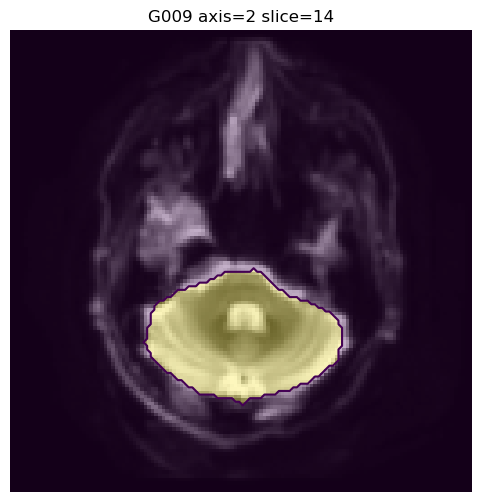

In [6]:
from vibes_pipe.viz import SliceSpec, plot_image_label_slice

batch = next(iter(train_loader))
# batch["image"] shape usually [B, D, H, W] or [B, H, W, D] depending on your pipeline

i = 0  # pick sample in batch
img = batch["image"][i]
lbl = batch["label"][i]
sid = batch["id"][i]

fig = plot_image_label_slice(
    img, lbl,
    spec=SliceSpec(axis=2, index=14, rotate_k=0),
    title=f"{sid} axis=2 slice=14",
    overlay=True,
    alpha=0.3,
    show_contour=True,
)

# D) Train-time Augmentation

For the train-time augmentation, we enforce the spatial augmentation (random scaling and rotation) and noise injection. Noise profile is extracted from GE subjects and Siemens subjects and stored in a separate folder in workspace. 

The config of augmentation can be altered via augmentation.yaml.
